In [1]:
import os

In [2]:
os.chdir(os.path.join(os.getcwd(), '..'))

In [3]:
os.getcwd()

'd:\\learning\\learning\\programing\\portfolio_projects\\1_image'

In [5]:
from src.components.optuna_model_selection.model import MRIFlexAttentionUNet
from src.components.optuna_model_selection.lightning_modules import MRIDataModule, MRIModule
import torch
from src.components.optuna_model_selection.dataset import MRIDataset
from src.constants import TRAIN_CSV
import gc
from src.utils import *
from tqdm.auto import tqdm

In [5]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
dummy_inp = torch.rand(1,3,256,256).to(device)

In [6]:
model = MRIFlexAttentionUNet(3,64,3,3,2,2,[3,5,3,5,3,5])

In [7]:
print(model)

MRIFlexAttentionUNet(
  (encoder_list): ModuleList(
    (0): EncoderBlock(
      (conv_block): ConvBlock(
        (conv_block): Sequential(
          (0): Sequential(
            (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU()
          )
          (1): Sequential(
            (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
            (2): ReLU()
          )
        )
      )
      (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): EncoderBlock(
      (conv_block): ConvBlock(
        (conv_block): Sequential(
          (0): Sequential(
            (0): Conv2d(64, 128, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
            (1): BatchNorm2d(128, eps=1e-

In [8]:
dummy_out = model(dummy_inp)

In [9]:
dummy_out.shape

torch.Size([1, 3, 256, 256])

In [10]:
datamodule = MRIDataModule()

In [11]:
datamodule.setup()

In [12]:
train_dataloader = datamodule.train_dataloader()
dev_dataloader = datamodule.val_dataloader()
test_dataloader = datamodule.test_dataloader()

In [14]:
'''ds = MRIDataset(TRAIN_CSV)

for i in range(len(ds)):
    img, mask = ds[i]
    if img.shape != mask.shape:
        print(img.shape, mask.shape)
        '''

'ds = MRIDataset(TRAIN_CSV)\n\nfor i in range(len(ds)):\n    img, mask = ds[i]\n    if img.shape != mask.shape:\n        print(img.shape, mask.shape)\n        '

In [ ]:
images, masks = next(iter(train_dataloader))
imgs = iter(images)

msks = iter(masks)


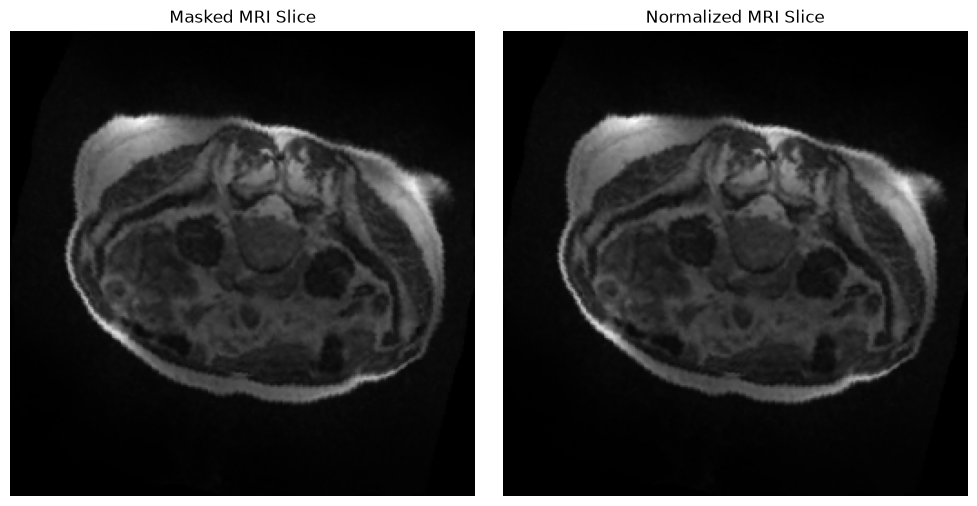

In [41]:
img = next(imgs)[1]
msk = next(msks)
show_mask_img_from_tensor(img, msk)

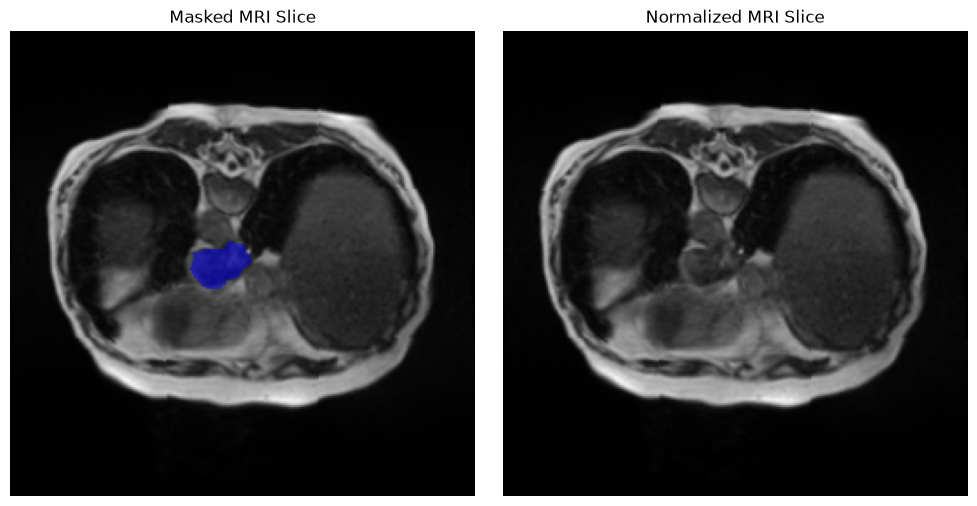

In [44]:
images, masks = next(iter(test_dataloader))
imgs = iter(images)

msks = iter(masks)
img = next(imgs)[1]
msk = next(msks)
show_mask_img_from_tensor(img, msk)

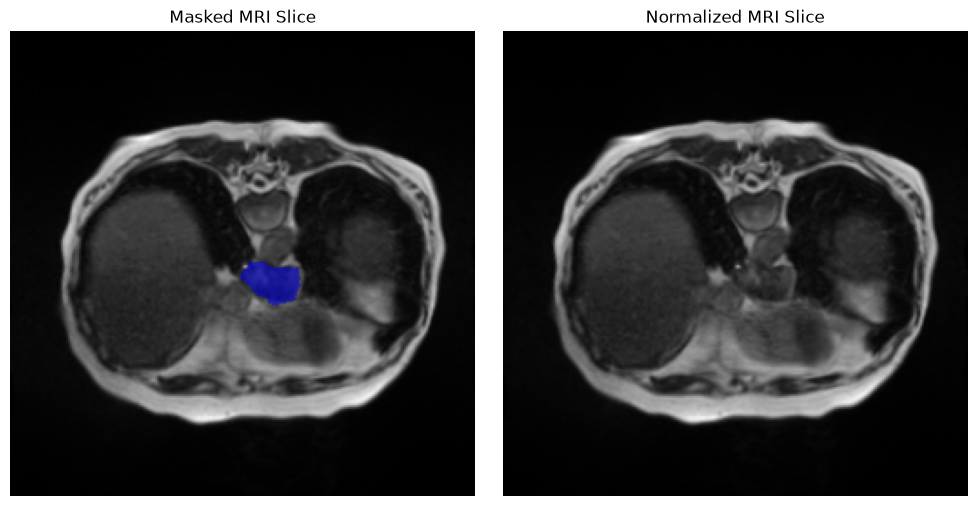

In [45]:
images, masks = next(iter(dev_dataloader))
imgs = iter(images)

msks = iter(masks)
img = next(imgs)[1]
msk = next(msks)
show_mask_img_from_tensor(img, msk)

In [46]:
os.cpu_count()

18

In [ ]:
os.cpu_count()

import os
if os.environ.get('KAGGLE_KERNEL_RUN_TYPE', None) is not None:
    from src.constants.kaggle import *

else:
    from src.constants.local import *
from torchvision.transforms import v2
from torch.utils.data import DataLoader
import time
import gc
import torch

In [35]:
from src.components.optuna_model_selection.dataset import MRIDataset

In [53]:
def num_workers_test(verbose = True): 

    if verbose:
        stats = {}
    train_transform = v2.Compose([
                v2.Resize(280),
                v2.RandomCrop(256),
                v2.RandomHorizontalFlip(0.5),
                v2.RandomVerticalFlip(0.5),
                v2.RandomRotation(15),
                v2.RandomApply([v2.ElasticTransform()], p=0.5),
                v2.RandomApply([v2.ColorJitter(brightness=0.2, contrast=0.2)], p=0.5)
            ])
    dataset = MRIDataset(TRAIN_CSV, transform = train_transform)#! gpu to cuda
    device = torch.device('cpu')
    num_batches = 40
    warmup = 2
    devices = 1
    best_time = float('inf')
    best_worker = 0

    for workers in range(0, os.cpu_count()-1, 2):
        wait_times, work_times = [], []

        dataloader = DataLoader(dataset, 32, True, num_workers=workers)

        end_of_prev = time.time()

        try:
            data_iter = iter(dataloader)

            for batch_idx in range(num_batches):

                data = next(data_iter)
                start_of_current = time.time()
                wait_times.append(start_of_current - end_of_prev)

                img, mask = data
                img = img.to(device)
                mask = mask.to(device)

                if device.type == 'cuda':
                    torch.cuda.synchronize()

                end_of_current = time.time()
                curr_time = end_of_current - start_of_current
                work_times.append(curr_time)
                                
                end_of_prev = end_of_current

            if len(work_times) > warmup:
                avg_work = np.mean(work_times[warmup:])
                avg_wait = np.mean(wait_times[warmup:])
                act_time = avg_work + avg_wait

                if act_time < best_time:
                    best_time = act_time
                    best_worker = workers

                #else: 
                    #break

                print(f'workers: {workers}, time: {act_time}')

                if verbose:
                    stats[workers] = [avg_wait, avg_work, act_time]
                    


        except StopIteration:

            print(
                1
            )

        except RuntimeError as e:
            print(2)

        finally:
            del dataloader
            gc.collect()
            if torch.cuda.is_available():
                torch.cuda.empty_cache()

    if verbose:
        return best_worker // devices, best_time, dict(sorted(stats.items(), key=lambda item: item[1][-1]))

    
    return best_worker // devices, best_time









In [6]:
from src.entity.config_entity import ModelCreationEntity

entity = ModelCreationEntity()

Benchmarking optimal batch size...
Batch size 32 is valid
Benchmarking optimal number of workers...
workers: 0, time: 0.748
workers: 2, time: 0.817
workers: 4, time: 0.422
workers: 6, time: 0.354
workers: 8, time: 0.264
workers: 10, time: 0.253
workers: 12, time: 0.208
workers: 14, time: 0.156
workers: 16, time: 0.177
The optial number of effective workers: 14


In [11]:
entity.num_workers_test()

workers: 0, time: 0.6193178129196167
workers: 2, time: 0.8583314323425293
workers: 4, time: 0.41232685089111326
workers: 6, time: 0.3228296661376953
workers: 8, time: 0.27171547889709474
workers: 10, time: 0.24593903064727785
workers: 12, time: 0.23231138229370119
workers: 14, time: 0.18007893562316893
workers: 16, time: 0.17771769046783448


(16, np.float64(0.17771769046783448))

In [10]:
entity.batch_size

32

16